In [1]:
import json
import gzip

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

import scipy.sparse as sp

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm 
from datetime import datetime

In [2]:
def load(path):
    open_func = gzip.open if path.endswith(".gz") else open
    with open_func(path, "rt", encoding="utf-8") as f:
        return json.load(f)

In [3]:
train = load("data/rtvslo_train.json")
test = load("data/rtvslo_test.json")


In [4]:
def extract_subtopics(data):
    for clanek in data:
        subtopics = clanek["url"].split("/")[3:-2]
        clanek["subtopics"] = subtopics
extract_subtopics(train)
extract_subtopics(test)

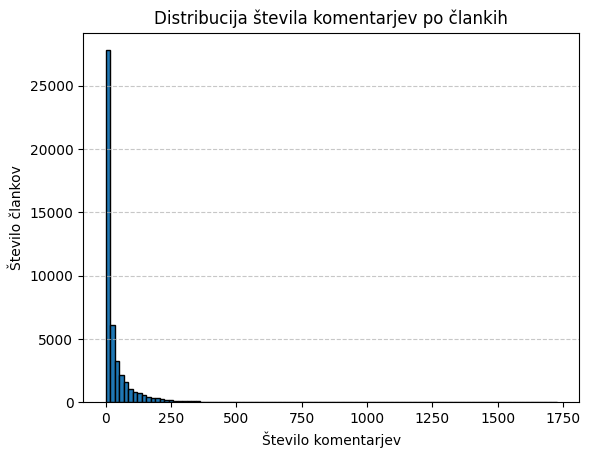

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

# Primer podatkov: vsak element je število komentarjev na določenem članku
komentarji_na_clanek = []
for clanek in train:
    # Dodamo število komentarjev na članek
    komentarji_na_clanek.append(clanek["n_comments"])
# Zamenjaj s tvojimi podatki

# Uporabi histogram za združevanje vrednosti v bine
plt.hist(komentarji_na_clanek, bins=100, edgecolor='black')

plt.xlabel('Število komentarjev')
plt.ylabel('Število člankov')
plt.title('Distribucija števila komentarjev po člankih')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [8]:
dict = {}
dict_clankov = {}
for clanek in train:
    for subtopic in clanek["subtopics"]:
        if subtopic not in dict:
            dict[subtopic] = 0
        if subtopic not in dict_clankov:
            dict_clankov[subtopic] = 0
        dict_clankov[subtopic] += clanek["n_comments"]
        dict[subtopic] += 1
for object in dict:
    print(f"{object}: {dict_clankov[object] / dict[object]}")


znanost-in-tehnologija: 34.34827377347062
na-testu: 20.8
gospodarstvo: 42.13204401467156
slovenija: 57.90518596123625
svet: 57.582701946613824
zabava-in-slog: 15.5560484558949
zanimivosti: 10.591036414565826
kultura: 5.567450321858383
drugo: 9.617977528089888
okolje: 41.453226613306654
narava: 30.923076923076923
kulinarika: 17.044025157232703
onesnazevanje: 19.96153846153846
s-in-j-amerika: 66.81818181818181
azija-z-oceanijo: 36.74220032840722
stevilke: 26.645569620253166
evropa: 46.04264909847434
dediscina: 8.819753086419754
avtomobilnost: 30.768759571209802
afrika: 21.93238434163701
razstave: 2.282608695652174
kolumne: 45.450819672131146
matevz-dular: 13.0
film-in-tv: 6.781867145421903
crna-kronika: 22.12099644128114
vizualna-umetnost: 4.508264462809917
ture-avanture: 13.533714285714286
prevozna-sredstva: 15.714285714285714
aljosa-masten: 45.0
lepota-bivanja: 42.82142857142857
popkultura: 11.532128514056225
retro: 15.19047619047619
znanost: 12.0
znani: 10.340529931305202
druzabno: 12

In [ ]:
lambda_est = np.mean(komentarji_na_clanek)
print(f"Ocenjena λ (povprečje): {lambda_est}")

In [1]:
from transformers import MarianMTModel, MarianTokenizer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "Helsinki-NLP/opus-mt-tc-bible-big-sla-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name).to(device)

def translate(texts):
    batch = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
    gen = model.generate(**batch)
    return [tokenizer.decode(t, skip_special_tokens=True) for t in gen]
print(translate(["Zdravo, kako si?"]))

c:\Users\Matej\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['Hi, how are you?']


In [15]:
from deep_translator import GoogleTranslator

sl_text = train[0]["title"]
translated = GoogleTranslator(source='sl', target='en').translate(sl_text)

print("Original:", sl_text)
print("Prevedeno:", translated)


Original: Plutonova sonda New Horizons dobiva kar dve tarči za ceno ene
Prevedeno: Pluto's New Horizons probe gets two targets for the price of one


In [ ]:
import nltk
from nltk.corpus import stopwords

# naložimo slovenske stop besede
stop_words = stopwords.words("slovene")
with open("SloStopWords.txt", "r", encoding="utf-8") as file:
    content = file.read()
content = content.split("\n")
content = [line.strip() for line in content if line.strip() != ""]  # Remove empty lines
content[0]= "ali"
slovene_stopwords = content+stop_words

In [ ]:
def extract(data):
    for clanek in data:
        topics = clanek["url"].split("/")[3:-2]
        clanek["topics"] = " ".join(topics)
    content = ["\n".join([a["title"]] + a["paragraphs"]) for a in data]
    topics = [[a.get("topics", "unknown")] for a in data]

    # izvlečemo dan v tednu (0=ponedeljek, 6=nedelja)
    weekdays = [[datetime.strptime(a["date"], "%Y-%m-%dT%H:%M:%S").weekday()] for a in data]

    return content, topics, weekdays

In [ ]:
device = "cpu"
def dense_to_dataset(X, y):
    return TensorDataset(torch.from_numpy(X), torch.from_numpy(y).unsqueeze(1).float())


def torch_fit(dataset, lambda_=0, batch_size=1000, lr=0.1, epochs=30, collate_fn=None):
    loader = DataLoader(dataset, shuffle=True, batch_size=batch_size, collate_fn=collate_fn)

    class Linear(nn.Module):
        def __init__(self, inputs):
            super().__init__()
            self.linear = nn.Linear(inputs, 1)

        def forward(self, x):
            return self.linear(x)

    model = Linear(dataset[0][0].shape[0])
    model = model.to(device)

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=lambda_)

    def train(dataloader, model, loss_fn, optimizer):
        model.train()
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            pred = model(X)
            loss = loss_fn(pred, y)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    def test(dataloader, model, loss_fn):
        size = len(dataloader.dataset)
        num_batches = len(dataloader)
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for X, y in dataloader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                test_loss += loss_fn(pred, y).item()
        test_loss /= num_batches
        print(f"Avg loss: {test_loss:>8f} \n")

    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        train(loader, model, loss_fn, optimizer)
        if (t + 1) % 5 == 0:
            test(loader, model, loss_fn)

    return model


def torch_predict(model, dataset):
    model.eval()
    x = dataset[:][0]
    with torch.no_grad():
        x = x.to(device)
        pred = model(x)
    return np.array(pred).reshape(-1)

In [ ]:
class RTVSlo:

    def fit(self, train_data: list):
            content, topics, weekdays = extract(train_data)

            self.vectorizer = TfidfVectorizer(min_df=10, max_features=20000,stop_words=slovene_stopwords, ngram_range=(1, 2), lowercase=True)
            X_text = self.vectorizer.fit_transform(content)

            self.onehot_topics = OneHotEncoder(handle_unknown="ignore", max_categories=50)
            X_topics = self.onehot_topics.fit_transform(topics)

            self.onehot_days = OneHotEncoder(handle_unknown="ignore", categories='auto')
            X_days = self.onehot_days.fit_transform(weekdays)

            X = sp.hstack([X_text, X_topics, X_days]).astype(np.float32).toarray()
            y = np.sqrt(np.array([d['n_comments'] for d in train_data]))

            self.torch_model = torch_fit(dense_to_dataset(X, y), lambda_=0.00001)

    def predict(self, test_data: list):
        content, topics, weekdays = extract(test_data)

        X_text = self.vectorizer.transform(content)
        X_topics = self.onehot_topics.transform(topics)
        X_days = self.onehot_days.transform(weekdays)

        X = sp.hstack([X_text, X_topics, X_days]).astype(np.float32).toarray()

        preds = torch_predict(self.torch_model, dense_to_dataset(X, np.zeros(len(X))))
        preds = np.square(preds)
        preds = np.clip(preds, 0, None)

        return preds

In [ ]:
m = RTVSlo()

In [ ]:
def test_mae(val_data, model):
    preds = model.predict(val_data)
    y = np.array([d['n_comments'] for d in val_data])
    mae = mean_absolute_error(y, preds)
    print(f"MAE: {mae:.2f}")
    return mae

In [ ]:
n = len(train)
train_data, val_data = train_test_split(train, test_size=0.1, random_state=42)
m.fit(train_data)
test_mae(val_data, m)

In [ ]:
    p = m.predict(test)

    np.savetxt('example.txt', p, fmt='%f')